# YOLO11 Fine-Tuning - Football Pitch Landmark Detection

Fine-tuning **YOLO11** for football pitch calibration using the Roboflow dataset
[`football-field-detection`](https://universe.roboflow.com/roboflow-jvuqo/football-field-detection-f07vi).

Instead of training one `pitch` pose instance with 32 attached keypoints, each of the
32 pitch landmarks is converted into its own small bounding-box class. At inference
time, the center of each detected box is used as the landmark coordinate.

This follows the approach described in [`Calibrating Football Fields with Keypoints (Part 1/2)`](https://medium.com/@akbarnezhad1380/calibrating-football-fields-with-keypoints-part-1-3-88fa4aad4d6e), using the same Roboflow `football-field-detection` dataset.


`32 pose keypoints -> 32 object-detection classes -> box centers -> homography`

The original Roboflow pose labels are preserved. A separate converted dataset is
created for object-detection training.


## 1. Environment setup & GPU check


In [1]:
import os
import glob

IN_COLAB = "COLAB_GPU" in os.environ or "google.colab" in str(get_ipython())
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IN_COLAB:
    PLATFORM = "colab"
    WORK_DIR = "/content"
elif IN_KAGGLE:
    PLATFORM = "kaggle"
    WORK_DIR = "/kaggle/working"
else:
    PLATFORM = "local"
    WORK_DIR = os.getcwd()

os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)

print(f"Detected platform: {PLATFORM}")
print(f"Working directory: {WORK_DIR}")


Detected platform: colab
Working directory: /content


In [2]:
# GPU check - make sure a GPU runtime/accelerator is actually attached before training
!nvidia-smi


Mon Sep 28 18:40:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
%pip install -q ultralytics roboflow supervision pyyaml pandas matplotlib

import ultralytics
ultralytics.checks()


Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)


## 2. Download the original Roboflow dataset

The source dataset contains one `pitch` object per image with **32 ordered
keypoints**. We download that original representation first because its keypoint
coordinates and indices define the 32 landmark classes used in the converted
detection dataset.

The Roboflow API key (Roboflow dashboard -> Settings -> API Keys) is requested with `getpass` so it is not stored in the notebook.

Set `DATASET_VERSION` to the version number you want (check the "Versions" tab on the
[dataset page](https://universe.roboflow.com/roboflow-jvuqo/football-field-detection-f07vi) -
version `1` is the original release. Later versions have more data/augmentation).


In [4]:
DATASET_WORKSPACE = "roboflow-jvuqo"
DATASET_PROJECT = "football-field-detection-f07vi"
DATASET_VERSION = 18

# Look only for the original pose dataset, not for the converted dataset created later.
existing_matches = [
    p for p in glob.glob(os.path.join(WORK_DIR, "football-field-detection*", "data.yaml"))
    if "landmark-detect" not in p
]

if existing_matches:
    DATASET_DIR = os.path.dirname(existing_matches[0])
    print(f"Found existing source dataset, skipping download: {DATASET_DIR}")
else:
    from getpass import getpass
    from roboflow import Roboflow

    ROBOFLOW_API_KEY = getpass("Enter your Roboflow API key: ")

    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(DATASET_WORKSPACE).project(DATASET_PROJECT)
    version = project.version(DATASET_VERSION)

    # YOLOv8 pose TXT is also compatible with the YOLO11 pose label layout:
    # class xc yc w h  kp1_x kp1_y kp1_v ... kp32_x kp32_y kp32_v
    dataset = version.download("yolov8")
    DATASET_DIR = dataset.location

    print(f"Dataset downloaded to: {DATASET_DIR}")


Enter your Roboflow API key: ··········
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-field-detection-18 in yolov8:: 100%|██████████| 639/639 [00:00<00:00, 6500.53it/s]

Dataset downloaded to: /content/football-field-detection-18


In [5]:
# Confirm the source dataset structure.
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, "").count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for f in files[:3]:
        print("  " * (level + 1) + f)


football-field-detection-18/
  README.roboflow.txt
  README.dataset.txt
  data.yaml
  test/
    labels/
      55c9d1_5_7_png.rf.31a08956787c05582533cf75ca3d7aa9.txt
      ec783a_1_2_png.rf.3e304ae802884a190e80fd0328a90bab.txt
      42ba34_0_14_png.rf.5f3af5eb5ae85b311f56b446b1d9bce6.txt
    images/
      42ba34_6_8_png.rf.d1ccb8bab33b5d023f831c434c837c03.jpg
      42ba34_7_2_png.rf.cc33669c19c5704679fd207436615926.jpg
      798b45_9_10_png.rf.4d3264e43840455cc4b8875688bcb9f8.jpg
  valid/
    labels/
      08fd33_3_5_png.rf.8070d4798058311a163867d70771d1be.txt
      42ba34_0_6_png.rf.4d2df1b47d37886775bc5a07cc9cf8ca.txt
      2e57b9_2_2_png.rf.aca9ff8f95e2ec633fa50979ed26c941.txt
    images/
      0bfacc_1_11_png.rf.a5860bef53e0006fff804dac2cf2f520.jpg
      42ba34_5_5_png.rf.3d6cf0656b17f539b1e828013fc1a11f.jpg
      42ba34_9_6_png.rf.d76ee5da8e1712addc4dd3a940c9969b.jpg
  train/
    labels/
      a9f16c_0_15_png.rf.9e87ae22c40f8acc3a05274bf157e5fc.txt
      42ba34_2_3_png.rf.841abd5a0

In [6]:
import yaml

source_yaml_path = os.path.join(DATASET_DIR, "data.yaml")

with open(source_yaml_path) as f:
    source_cfg = yaml.safe_load(f)

print(yaml.dump(source_cfg, sort_keys=False))

kpt_shape = source_cfg.get("kpt_shape")
assert kpt_shape is not None, "Source data.yaml does not contain kpt_shape"
assert kpt_shape[0] == 32, f"Expected 32 keypoints, got {kpt_shape}"

NUM_LANDMARKS = kpt_shape[0]
print(f"Source dataset contains {NUM_LANDMARKS} pitch landmarks.")


flip_idx:
- 24
- 25
- 26
- 27
- 28
- 29
- 22
- 23
- 21
- 17
- 18
- 19
- 20
- 13
- 14
- 15
- 16
- 9
- 10
- 11
- 12
- 8
- 6
- 7
- 0
- 1
- 2
- 3
- 4
- 5
- 31
- 30
kpt_shape:
- 32
- 3
names:
- pitch
nc: 1
roboflow:
  license: CC BY 4.0
  project: football-field-detection-f07vi
  url: https://universe.roboflow.com/roboflow-jvuqo/football-field-detection-f07vi/dataset/18
  version: 18
  workspace: roboflow-jvuqo
test: ../test/images
train: ../train/images
val: ../valid/images

Source dataset contains 32 pitch landmarks.


## 3. Convert pose keypoints into 32 detection classes

Each visible pitch keypoint becomes a small square bounding box centered on the
original landmark coordinate. The class ID is the original keypoint index, so the
semantic ordering is preserved automatically.

For example:

- pose keypoint index `0` becomes detection class `0` (`TRC`)
- pose keypoint index `1` becomes detection class `1` (`TR18ML`)
- ...
- pose keypoint index `31` becomes detection class `31` (`CR`)

The article describes boxes of roughly **5% of pitch width** around each point.
`BOX_SIZE = 0.05` is used here as a practical normalized-image approximation and is
kept as one explicit parameter so it can be tested later.

Only keypoints marked visible (`v > 0`) and having valid normalized coordinates are
converted. Missing keypoints are not turned into artificial detection targets.

<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*I8n6fKQHuK1nzLyo31e0ow.png" width="800">


In [7]:
from pathlib import Path
import shutil

LANDMARK_NAMES = [
    "TRC", "TR18ML", "TR6ML", "TL6ML", "TL18ML", "TLC",
    "TR6MC", "TL6MC", "PL", "TR18MC", "TRArc", "TLArc",
    "TL18MC", "RML", "RMC", "LMC", "LML", "BR18MC",
    "BRArc", "BLArc", "BL18MC", "PR", "BR6MC", "BL6MC",
    "BRC", "BR18ML", "BR6ML", "BL6ML", "BL18ML", "BLC",
    "CL", "CR",
]

assert len(LANDMARK_NAMES) == NUM_LANDMARKS

BOX_SIZE = 0.05

CONVERTED_DATASET_DIR = os.path.join(
    WORK_DIR,
    f"football-field-detection-{DATASET_VERSION}-landmark-detect"
)

print(f"Converted dataset will be written to: {CONVERTED_DATASET_DIR}")


Converted dataset will be written to: /content/football-field-detection-18-landmark-detect


In [8]:
def convert_pose_label_to_detection(src_label_path: Path, dst_label_path: Path):
    """
    Convert a YOLO pose label into a YOLO detection label.

    Source line:
        class xc yc w h  kp1_x kp1_y kp1_v ... kp32_x kp32_y kp32_v

    Destination lines:
        landmark_class x_center y_center box_width box_height

    The landmark class ID is exactly the original pose keypoint index.
    """
    output_lines = []

    with src_label_path.open("r") as f:
        source_lines = [line.strip() for line in f if line.strip()]

    for line in source_lines:
        values = list(map(float, line.split()))

        if len(values) < 5 + NUM_LANDMARKS * 3:
            raise ValueError(
                f"{src_label_path}: expected at least "
                f"{5 + NUM_LANDMARKS * 3} values, got {len(values)}"
            )

        kp_values = values[5:5 + NUM_LANDMARKS * 3]

        for landmark_idx in range(NUM_LANDMARKS):
            x, y, visibility = kp_values[
                landmark_idx * 3 : landmark_idx * 3 + 3
            ]

            # No target should be created for an absent/unlabelled landmark.
            if visibility <= 0:
                continue

            # Ignore invalid / placeholder coordinates.
            if not (0.0 < x < 1.0 and 0.0 < y < 1.0):
                continue

            # Clip the box dimensions near image edges while preserving the
            # landmark itself as the box center.
            box_w = min(BOX_SIZE, 2.0 * min(x, 1.0 - x))
            box_h = min(BOX_SIZE, 2.0 * min(y, 1.0 - y))

            if box_w <= 0 or box_h <= 0:
                continue

            output_lines.append(
                f"{landmark_idx} {x:.6f} {y:.6f} "
                f"{box_w:.6f} {box_h:.6f}"
            )

    dst_label_path.parent.mkdir(parents=True, exist_ok=True)
    dst_label_path.write_text("\n".join(output_lines))


def convert_split(source_root: str, destination_root: str, split_folder: str):
    src_images = Path(source_root) / split_folder / "images"
    src_labels = Path(source_root) / split_folder / "labels"

    dst_images = Path(destination_root) / split_folder / "images"
    dst_labels = Path(destination_root) / split_folder / "labels"

    dst_images.mkdir(parents=True, exist_ok=True)
    dst_labels.mkdir(parents=True, exist_ok=True)

    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    image_paths = [
        p for p in src_images.iterdir()
        if p.suffix.lower() in image_extensions
    ]

    converted = 0
    for img_path in image_paths:
        shutil.copy2(img_path, dst_images / img_path.name)

        src_label = src_labels / f"{img_path.stem}.txt"
        dst_label = dst_labels / f"{img_path.stem}.txt"

        if src_label.exists():
            convert_pose_label_to_detection(src_label, dst_label)
        else:
            dst_label.write_text("")

        converted += 1

    print(f"{split_folder}: converted {converted} images")


# Recreate the converted dataset so stale labels from earlier experiments cannot remain.
if os.path.isdir(CONVERTED_DATASET_DIR):
    shutil.rmtree(CONVERTED_DATASET_DIR)

for split_folder in ("train", "valid", "test"):
    src_split = os.path.join(DATASET_DIR, split_folder)
    if os.path.isdir(src_split):
        convert_split(DATASET_DIR, CONVERTED_DATASET_DIR, split_folder)


train: converted 255 images
valid: converted 34 images
test: converted 28 images


In [9]:
# Build a new detection data.yaml.
detection_cfg = {
    "path": CONVERTED_DATASET_DIR,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": NUM_LANDMARKS,
    "names": {i: name for i, name in enumerate(LANDMARK_NAMES)},
}

# Remove test if the downloaded dataset does not contain it.
if not os.path.isdir(os.path.join(CONVERTED_DATASET_DIR, "test", "images")):
    detection_cfg.pop("test")

data_yaml_path = os.path.join(CONVERTED_DATASET_DIR, "data.yaml")

with open(data_yaml_path, "w") as f:
    yaml.safe_dump(detection_cfg, f, sort_keys=False)

print(yaml.safe_dump(detection_cfg, sort_keys=False))
print(f"Detection data.yaml: {data_yaml_path}")


path: /content/football-field-detection-18-landmark-detect
train: train/images
val: valid/images
test: test/images
nc: 32
names:
  0: TRC
  1: TR18ML
  2: TR6ML
  3: TL6ML
  4: TL18ML
  5: TLC
  6: TR6MC
  7: TL6MC
  8: PL
  9: TR18MC
  10: TRArc
  11: TLArc
  12: TL18MC
  13: RML
  14: RMC
  15: LMC
  16: LML
  17: BR18MC
  18: BRArc
  19: BLArc
  20: BL18MC
  21: PR
  22: BR6MC
  23: BL6MC
  24: BRC
  25: BR18ML
  26: BR6ML
  27: BL6ML
  28: BL18ML
  29: BLC
  30: CL
  31: CR

Detection data.yaml: /content/football-field-detection-18-landmark-detect/data.yaml


## 4. Verify the converted labels before training

This is an important sanity check. The colored rectangles should be centered on the
same landmarks that were represented by the original pose keypoints, and the text
next to each rectangle should show the correct landmark class name.


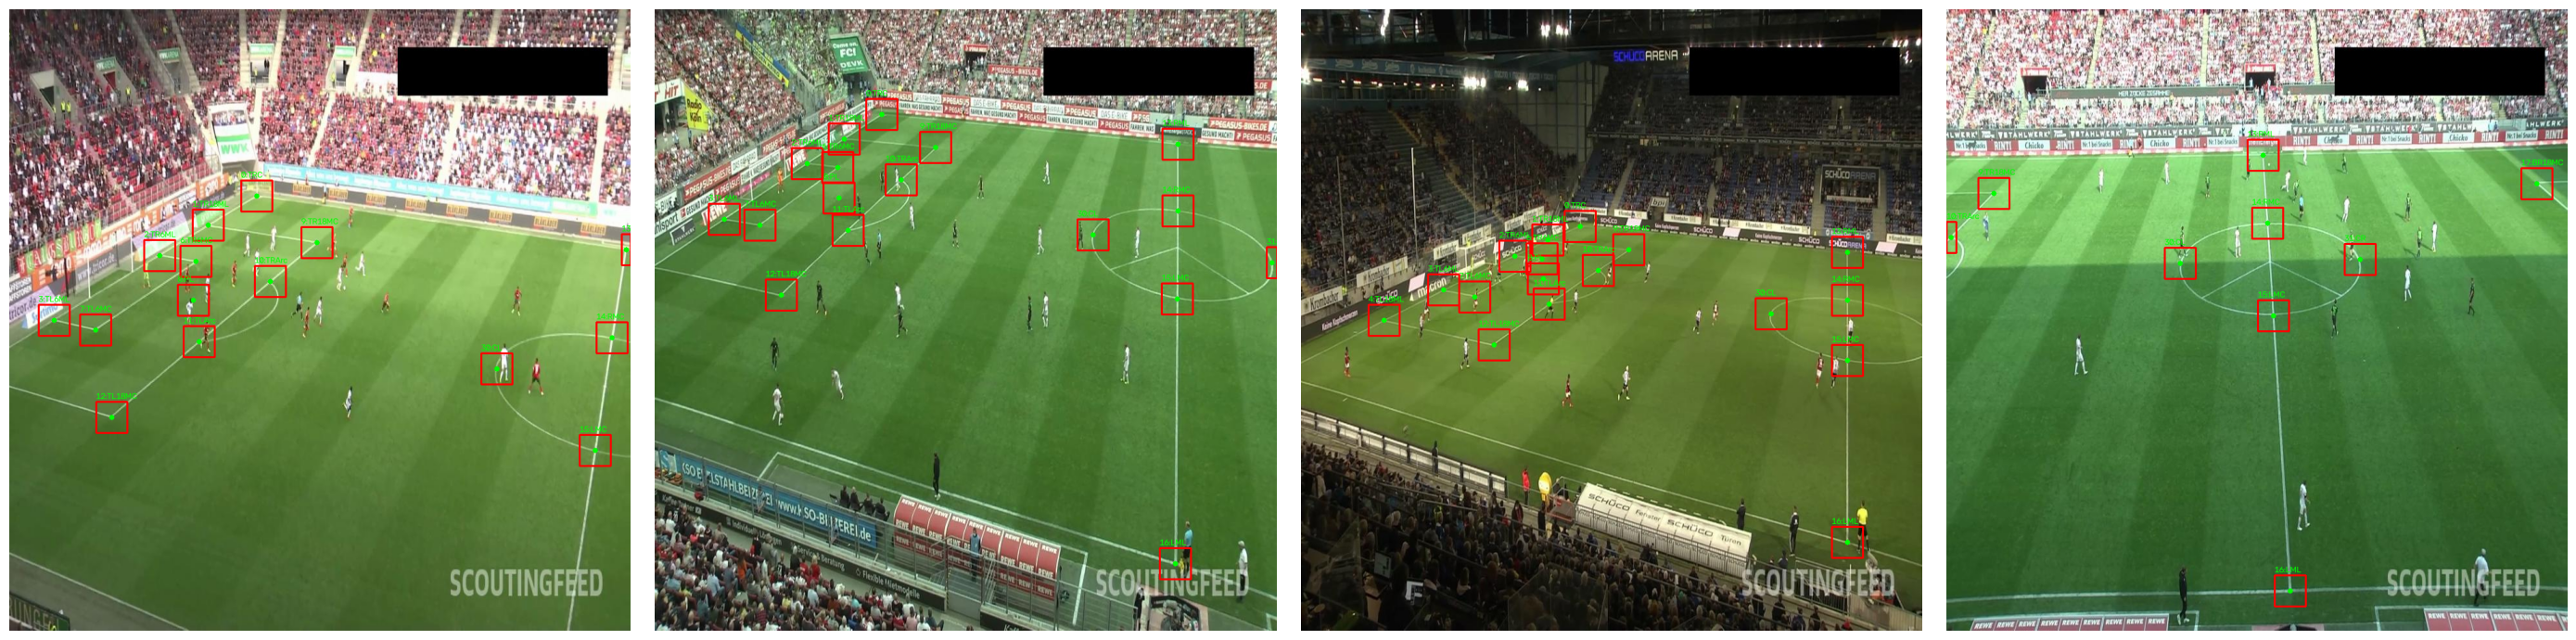

In [10]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

train_img_dir = os.path.join(CONVERTED_DATASET_DIR, "train", "images")
train_lbl_dir = os.path.join(CONVERTED_DATASET_DIR, "train", "labels")

all_imgs = []
for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"):
    all_imgs.extend(glob.glob(os.path.join(train_img_dir, ext)))

assert all_imgs, f"No converted training images found in {train_img_dir}"

sample_imgs = random.sample(all_imgs, k=min(4, len(all_imgs)))

fig, axes = plt.subplots(1, len(sample_imgs), figsize=(7 * len(sample_imgs), 7))
if len(sample_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_imgs):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    label_path = os.path.join(
        train_lbl_dir,
        Path(img_path).stem + ".txt"
    )

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                if not line.strip():
                    continue

                class_id, xc, yc, bw, bh = map(float, line.split())
                class_id = int(class_id)

                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.circle(img, (int(xc * w), int(yc * h)), 4, (0, 255, 0), -1)
                cv2.putText(
                    img,
                    f"{class_id}:{LANDMARK_NAMES[class_id]}",
                    (x1, max(15, y1 - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.45,
                    (0, 255, 0),
                    1,
                    cv2.LINE_AA,
                )

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 5. Train YOLO11 as a 32-class landmark detector

The configuration for the experiment:

- `yolo11m.pt`: lightweight YOLO11 detector
- `epochs=200`: baseline.
- `imgsz=960`: baseline.
- `batch=16`: baseline.
- `augment=False`, `mosaic=0`, `mixup=0`, `copy_paste=0`: avoid strong transforms
  that may make precise landmark localization harder.
- `fliplr=0`: do not horizontally flip landmarks because every landmark has its own
  semantic class.
- `cls=2.0`: increase classification-loss weight because distinguishing the 32
  landmark identities is essential for homography.

In [11]:
from ultralytics import YOLO

MODEL_SIZE = "yolo11m.pt"
EPOCHS = 200
IMG_SIZE = 960
BATCH_SIZE = 16
PATIENCE = 20
RUN_NAME = "pitch_landmarks_yolo11m_detect"

model = YOLO(MODEL_SIZE)

results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    device=0,

    # Optimizer / LR schedule
    optimizer="AdamW",
    cos_lr=True,

    # Restrained augmentation for precise landmark localization.
    augment=False,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
    fliplr=0.0,

    # Stronger landmark-class discrimination.
    cls=2.0,

    project=os.path.join(WORK_DIR, "runs_detect"),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
    val=True,
    seed=42,
)

RUN_DIR = os.path.join(WORK_DIR, "runs_detect", RUN_NAME)
print(f"Training run saved to: {RUN_DIR}")


Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/football-field-detection-18-landmark-detect/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=pitch_landmarks_yolo11m_det

## 6. Evaluate the trained detector

Each pitch landmark is an object-detection class,
so evaluation uses the standard YOLO **box precision, recall and mAP** metrics.

For homography, the global mAP is useful, but per-class performance is also important.
A model that consistently misses one or two landmark identities can still have a
good overall score while giving fewer usable correspondences in some camera views.


In [12]:
metrics = model.val(
    data=data_yaml_path,
    imgsz=IMG_SIZE,
    split="val",
    project=os.path.join(WORK_DIR, "runs_detect"),
    name=RUN_NAME + "_eval",
    exist_ok=True,
    plots=True,
)

EVAL_DIR = os.path.join(WORK_DIR, "runs_detect", RUN_NAME + "_eval")

print(f"Evaluation artifacts saved to: {EVAL_DIR}")
print("\n--- Landmark detection metrics ---")
print(f"Box mAP50:     {metrics.box.map50:.4f}")
print(f"Box mAP50-95:  {metrics.box.map:.4f}")
print(f"Box Precision: {metrics.box.mp:.4f}")
print(f"Box Recall:    {metrics.box.mr:.4f}")


Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 125 layers, 20,054,704 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2416.1±475.2 MB/s, size: 126.1 KB)
val: Scanning /content/football-field-detection-18-landmark-detect/valid/labels.cache... 34 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 34/34 11.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3s/it 3.9s
                   all         34        492      0.976      0.952       0.96      0.874
                   TRC         16         16      0.995          1      0.995      0.922
                TR18ML         16         16          1      0.896      0.988      0.867
                 TR6ML         16         16          1      0.867      0.995      0.875
                 TL6ML         13         13          1      0.911      0.925      0.845
           

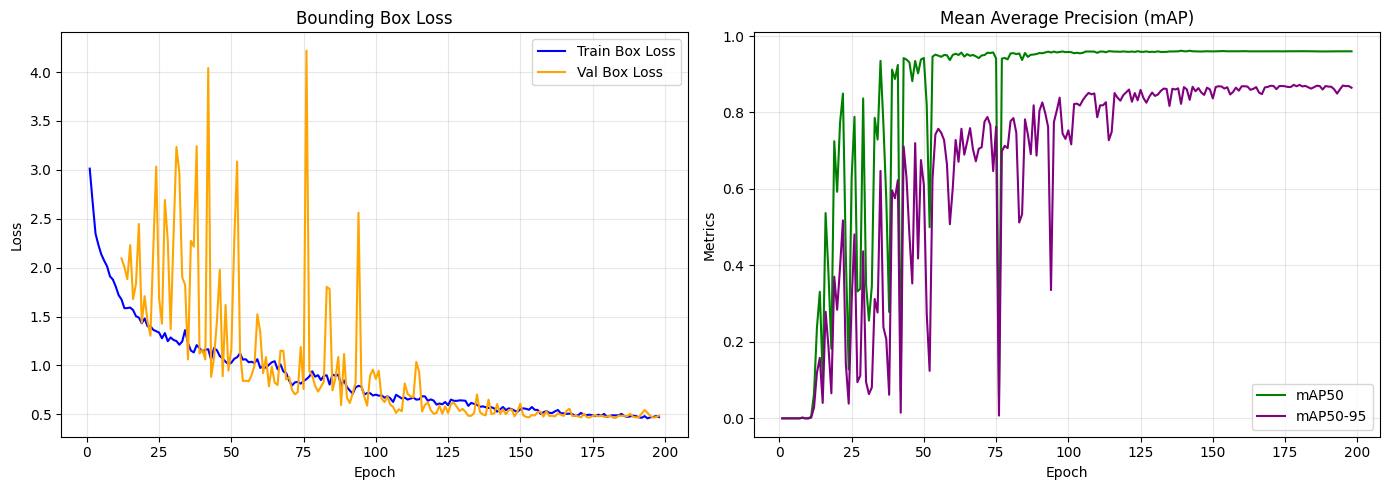

--- Final Validation Summary ---
Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 125 layers, 20,054,704 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2571.2±632.7 MB/s, size: 121.0 KB)
val: Scanning /content/football-field-detection-18-landmark-detect/valid/labels.cache... 34 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 34/34 5.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3s/it 3.8s
                   all         34        492      0.976      0.952       0.96      0.874
                   TRC         16         16      0.995          1      0.995      0.922
                TR18ML         16         16          1      0.896      0.988      0.867
                 TR6ML         16         16          1      0.867      0.995      0.875
                 TL6ML         13         13          1      0.911  

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os

results_file = os.path.join(RUN_DIR, "results.csv")
if os.path.exists(results_file):
    df_results = pd.read_csv(results_file)
    df_results.columns = df_results.columns.str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Curves
    axes[0].plot(df_results['epoch'], df_results['train/box_loss'], label='Train Box Loss', color='blue')
    axes[0].plot(df_results['epoch'], df_results['val/box_loss'], label='Val Box Loss', color='orange')
    axes[0].set_title('Bounding Box Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # mAP Curves
    axes[1].plot(df_results['epoch'], df_results['metrics/mAP50(B)'], label='mAP50', color='green')
    axes[1].plot(df_results['epoch'], df_results['metrics/mAP50-95(B)'], label='mAP50-95', color='purple')
    axes[1].set_title('Mean Average Precision (mAP)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Metrics')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("--- Final Validation Summary ---")
    final_metrics = model.val()
    print(f"mAP@0.5: {final_metrics.box.map50:.4f}")
    print(f"mAP@0.5:0.95: {final_metrics.box.map:.4f}")
else:
    print(f"Warning: Could not find results.csv at {results_file}")

In [14]:
import pandas as pd

summary_df = pd.DataFrame([{
    "box_mAP50": metrics.box.map50,
    "box_mAP50-95": metrics.box.map,
    "box_precision": metrics.box.mp,
    "box_recall": metrics.box.mr,
}])

print(summary_df.to_string(index=False))

metrics_csv_path = os.path.join(
    EVAL_DIR,
    "landmark_detection_metrics_summary.csv"
)
summary_df.to_csv(metrics_csv_path, index=False)

print(f"\nSaved metrics summary to {metrics_csv_path}")

# Per-class mAP50-95 makes it easy to identify weak landmark identities.
if getattr(metrics.box, "maps", None) is not None:
    per_class_df = pd.DataFrame({
        "class_id": range(NUM_LANDMARKS),
        "landmark": LANDMARK_NAMES,
        "mAP50-95": metrics.box.maps[:NUM_LANDMARKS],
    })

    # Lowest-performing classes
    lowest_df = per_class_df.sort_values(
        "mAP50-95",
        ascending=True
    )

    print("\nLowest-performing landmark classes:")
    print(lowest_df.head(10).to_string(index=False))

    # Highest-performing classes
    highest_df = per_class_df.sort_values(
        "mAP50-95",
        ascending=False
    )

    print("\nHighest-performing landmark classes:")
    print(highest_df.head(10).to_string(index=False))

    per_class_csv_path = os.path.join(
        EVAL_DIR,
        "per_landmark_map.csv"
    )
    per_class_df.to_csv(per_class_csv_path, index=False)


 box_mAP50  box_mAP50-95  box_precision  box_recall
  0.959821      0.873908       0.975556    0.951823

Saved metrics summary to /content/runs_detect/pitch_landmarks_yolo11m_detect_eval/landmark_detection_metrics_summary.csv

Lowest-performing landmark classes:
 class_id landmark  mAP50-95
        4   TL18ML  0.665000
       31       CR  0.691238
       26    BR6ML  0.742302
        5      TLC  0.753000
       30       CL  0.788706
       23    BL6MC  0.809839
       16      LML  0.816013
       17   BR18MC  0.833699
       12   TL18MC  0.841775
       20   BL18MC  0.844667

Highest-performing landmark classes:
 class_id landmark  mAP50-95
       29      BLC  0.995000
       28   BL18ML  0.995000
       10    TRArc  0.952171
        6    TR6MC  0.947000
       22    BR6MC  0.943044
       15      LMC  0.941968
       11    TLArc  0.934300
       19    BLArc  0.929000
       13      RML  0.922146
        0      TRC  0.922140


BoxPR_curve.png


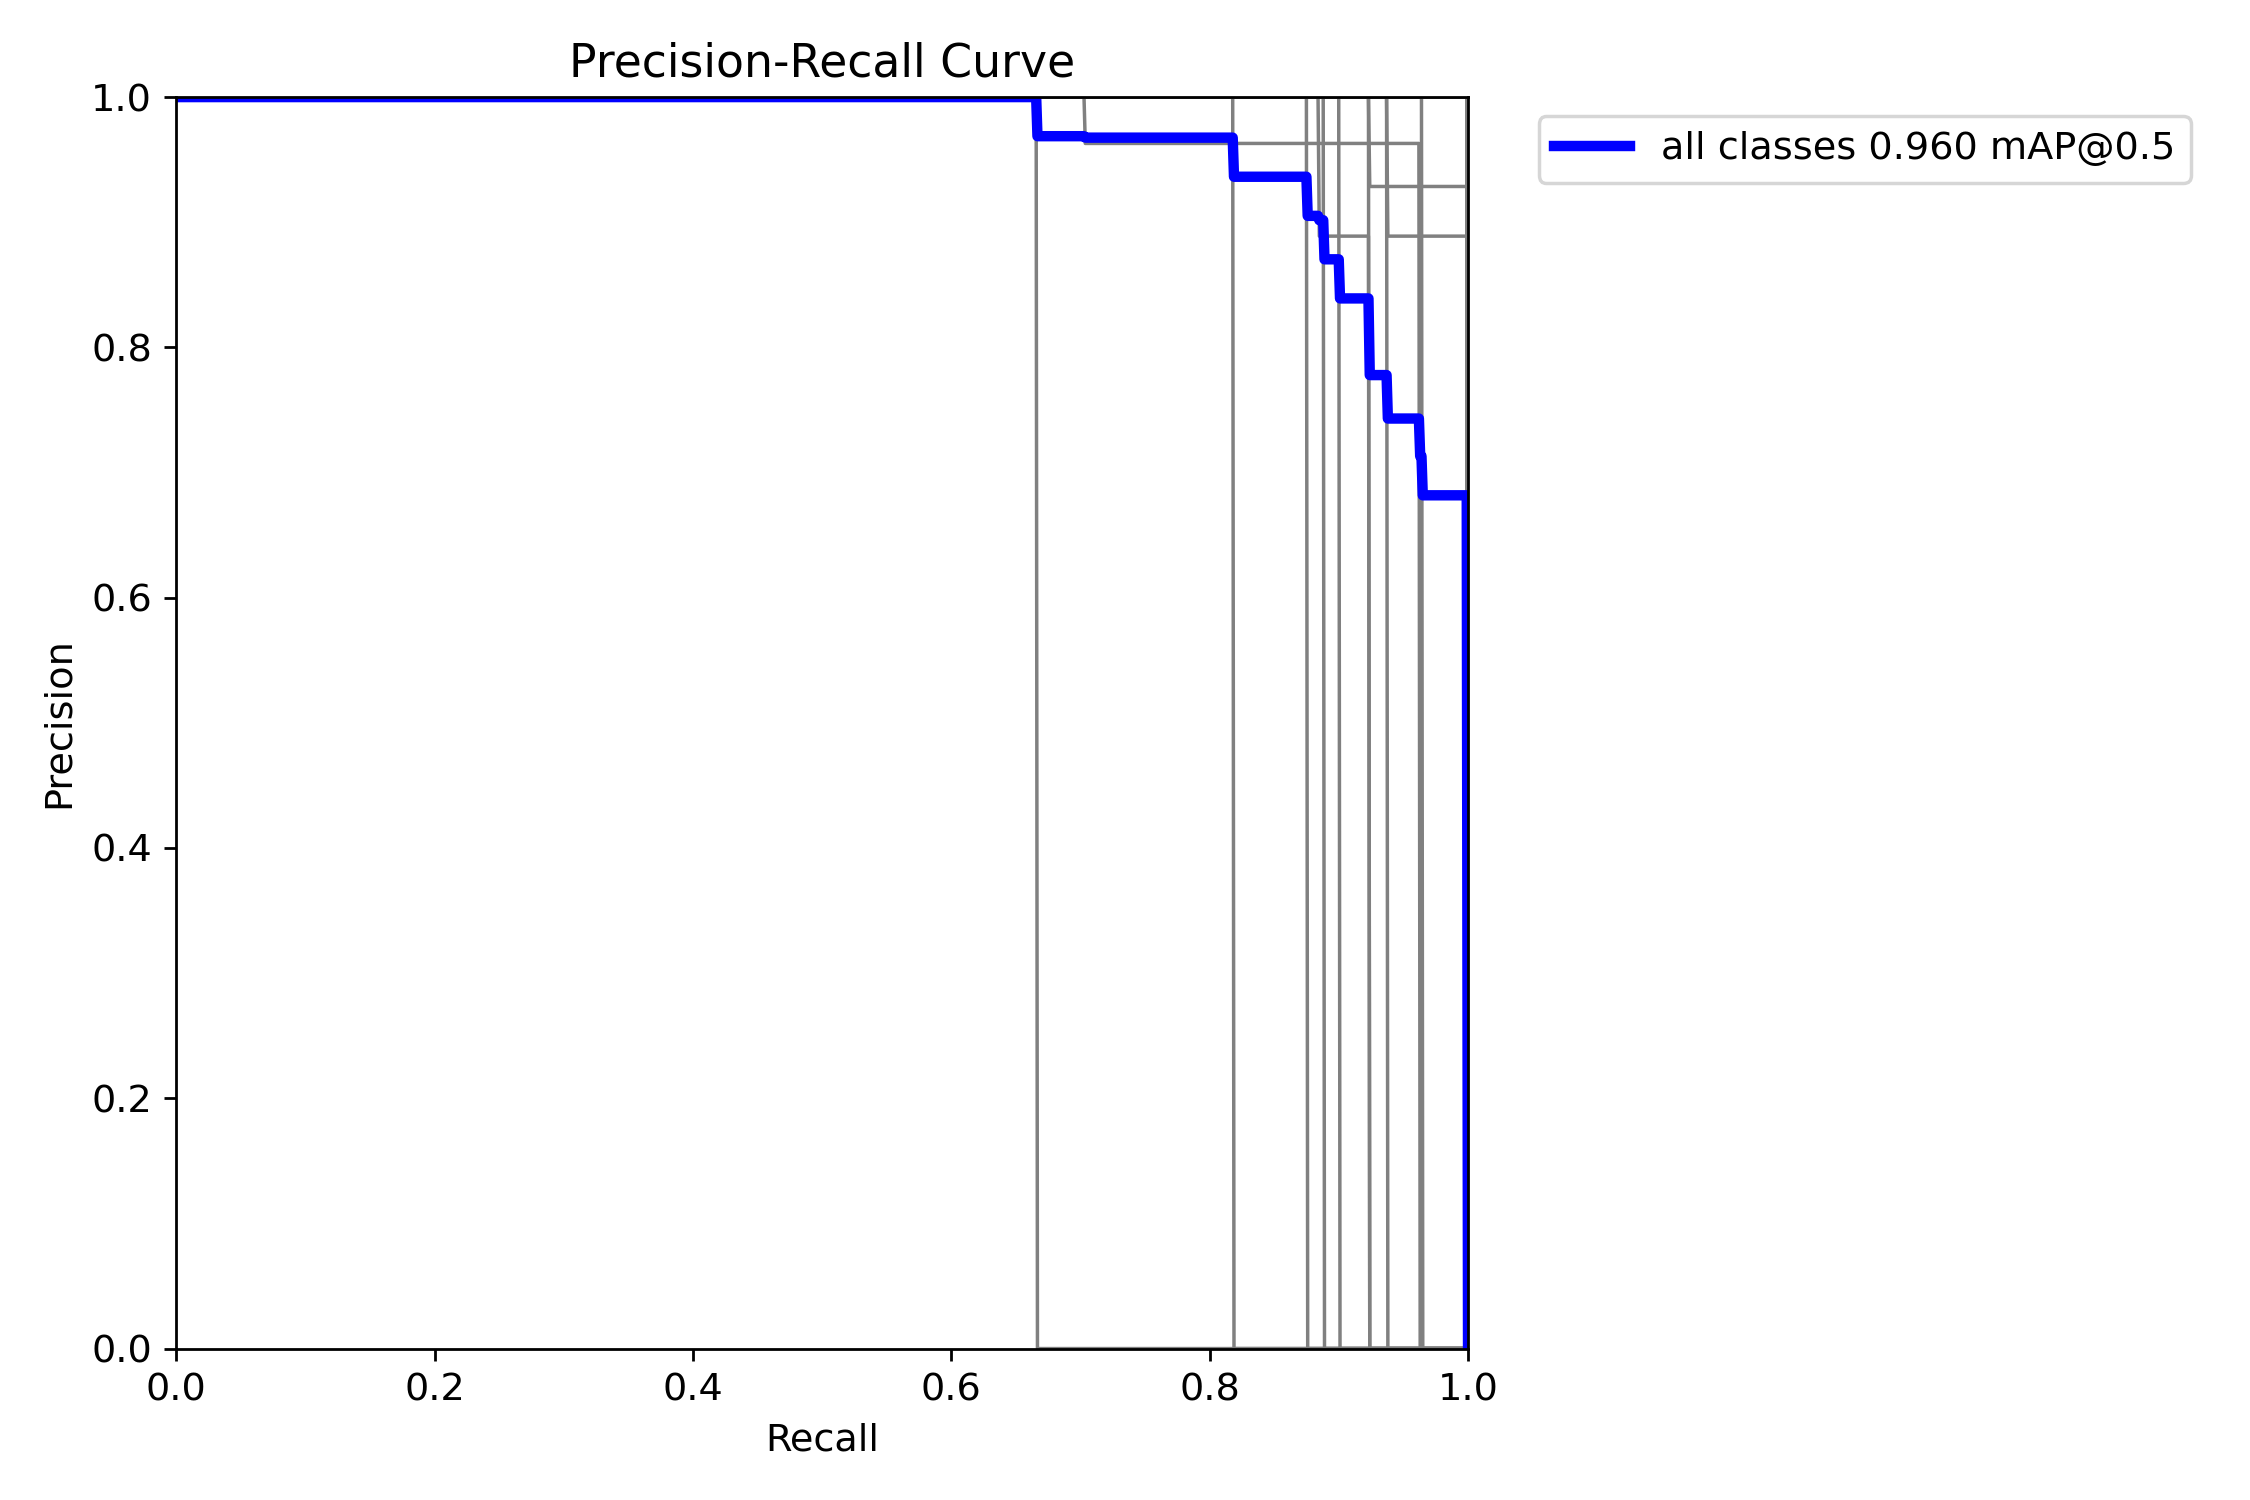

BoxF1_curve.png


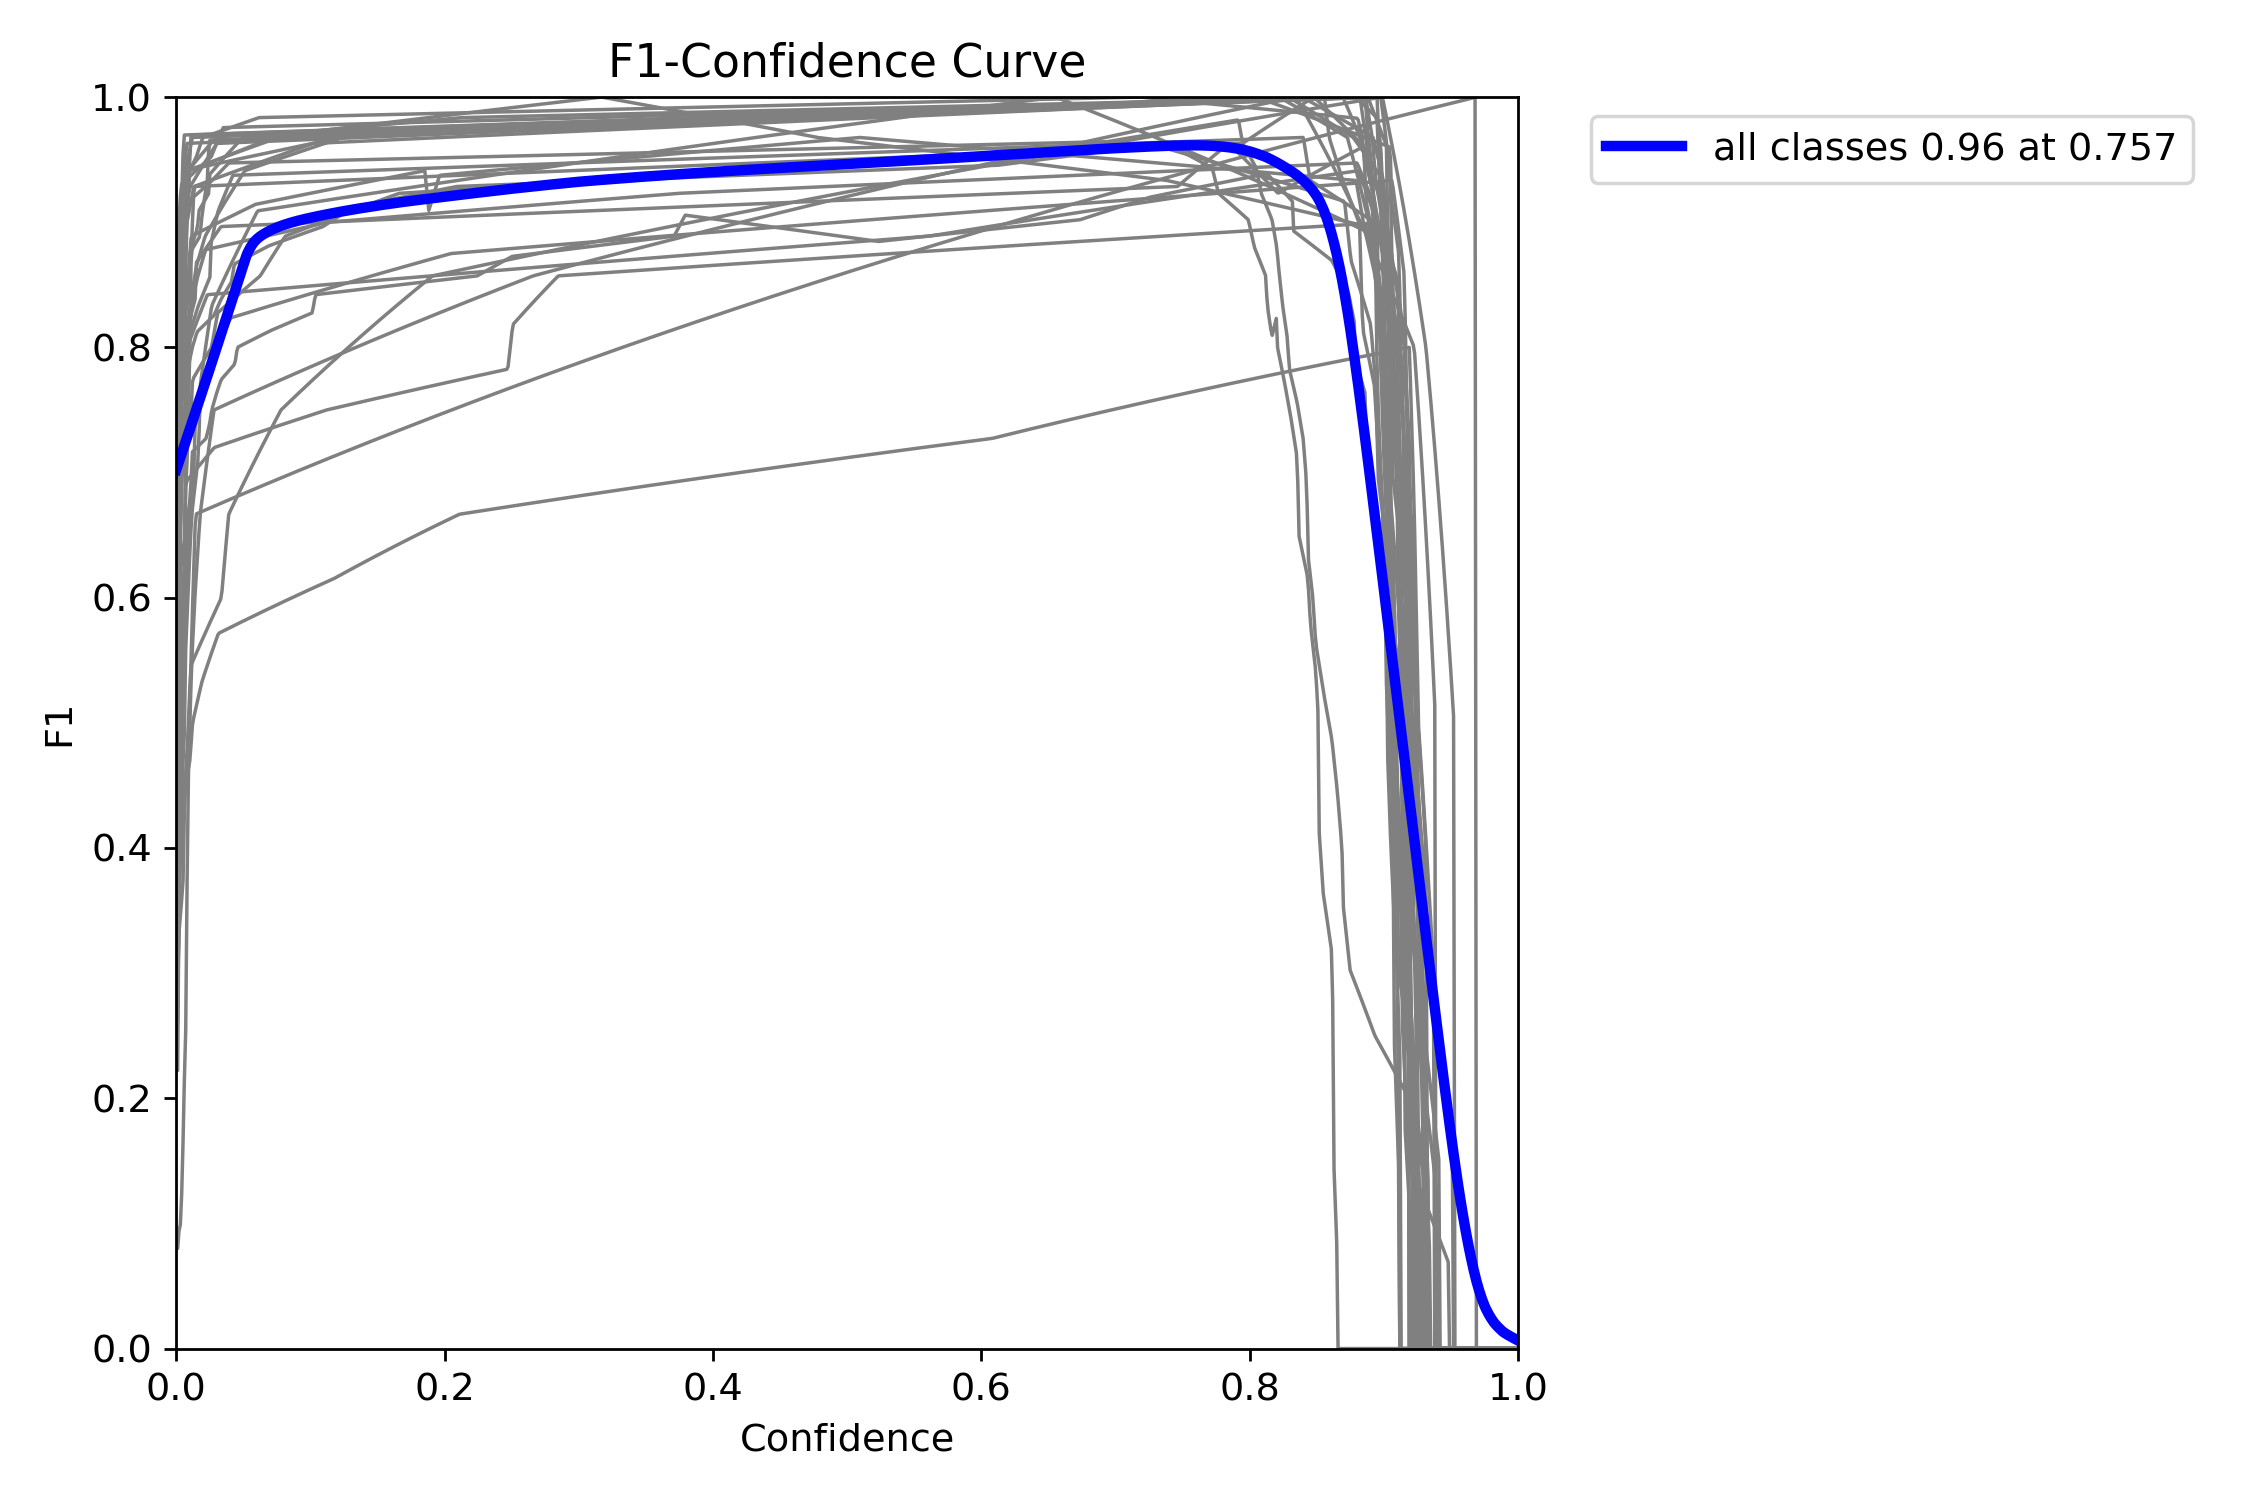

confusion_matrix.png


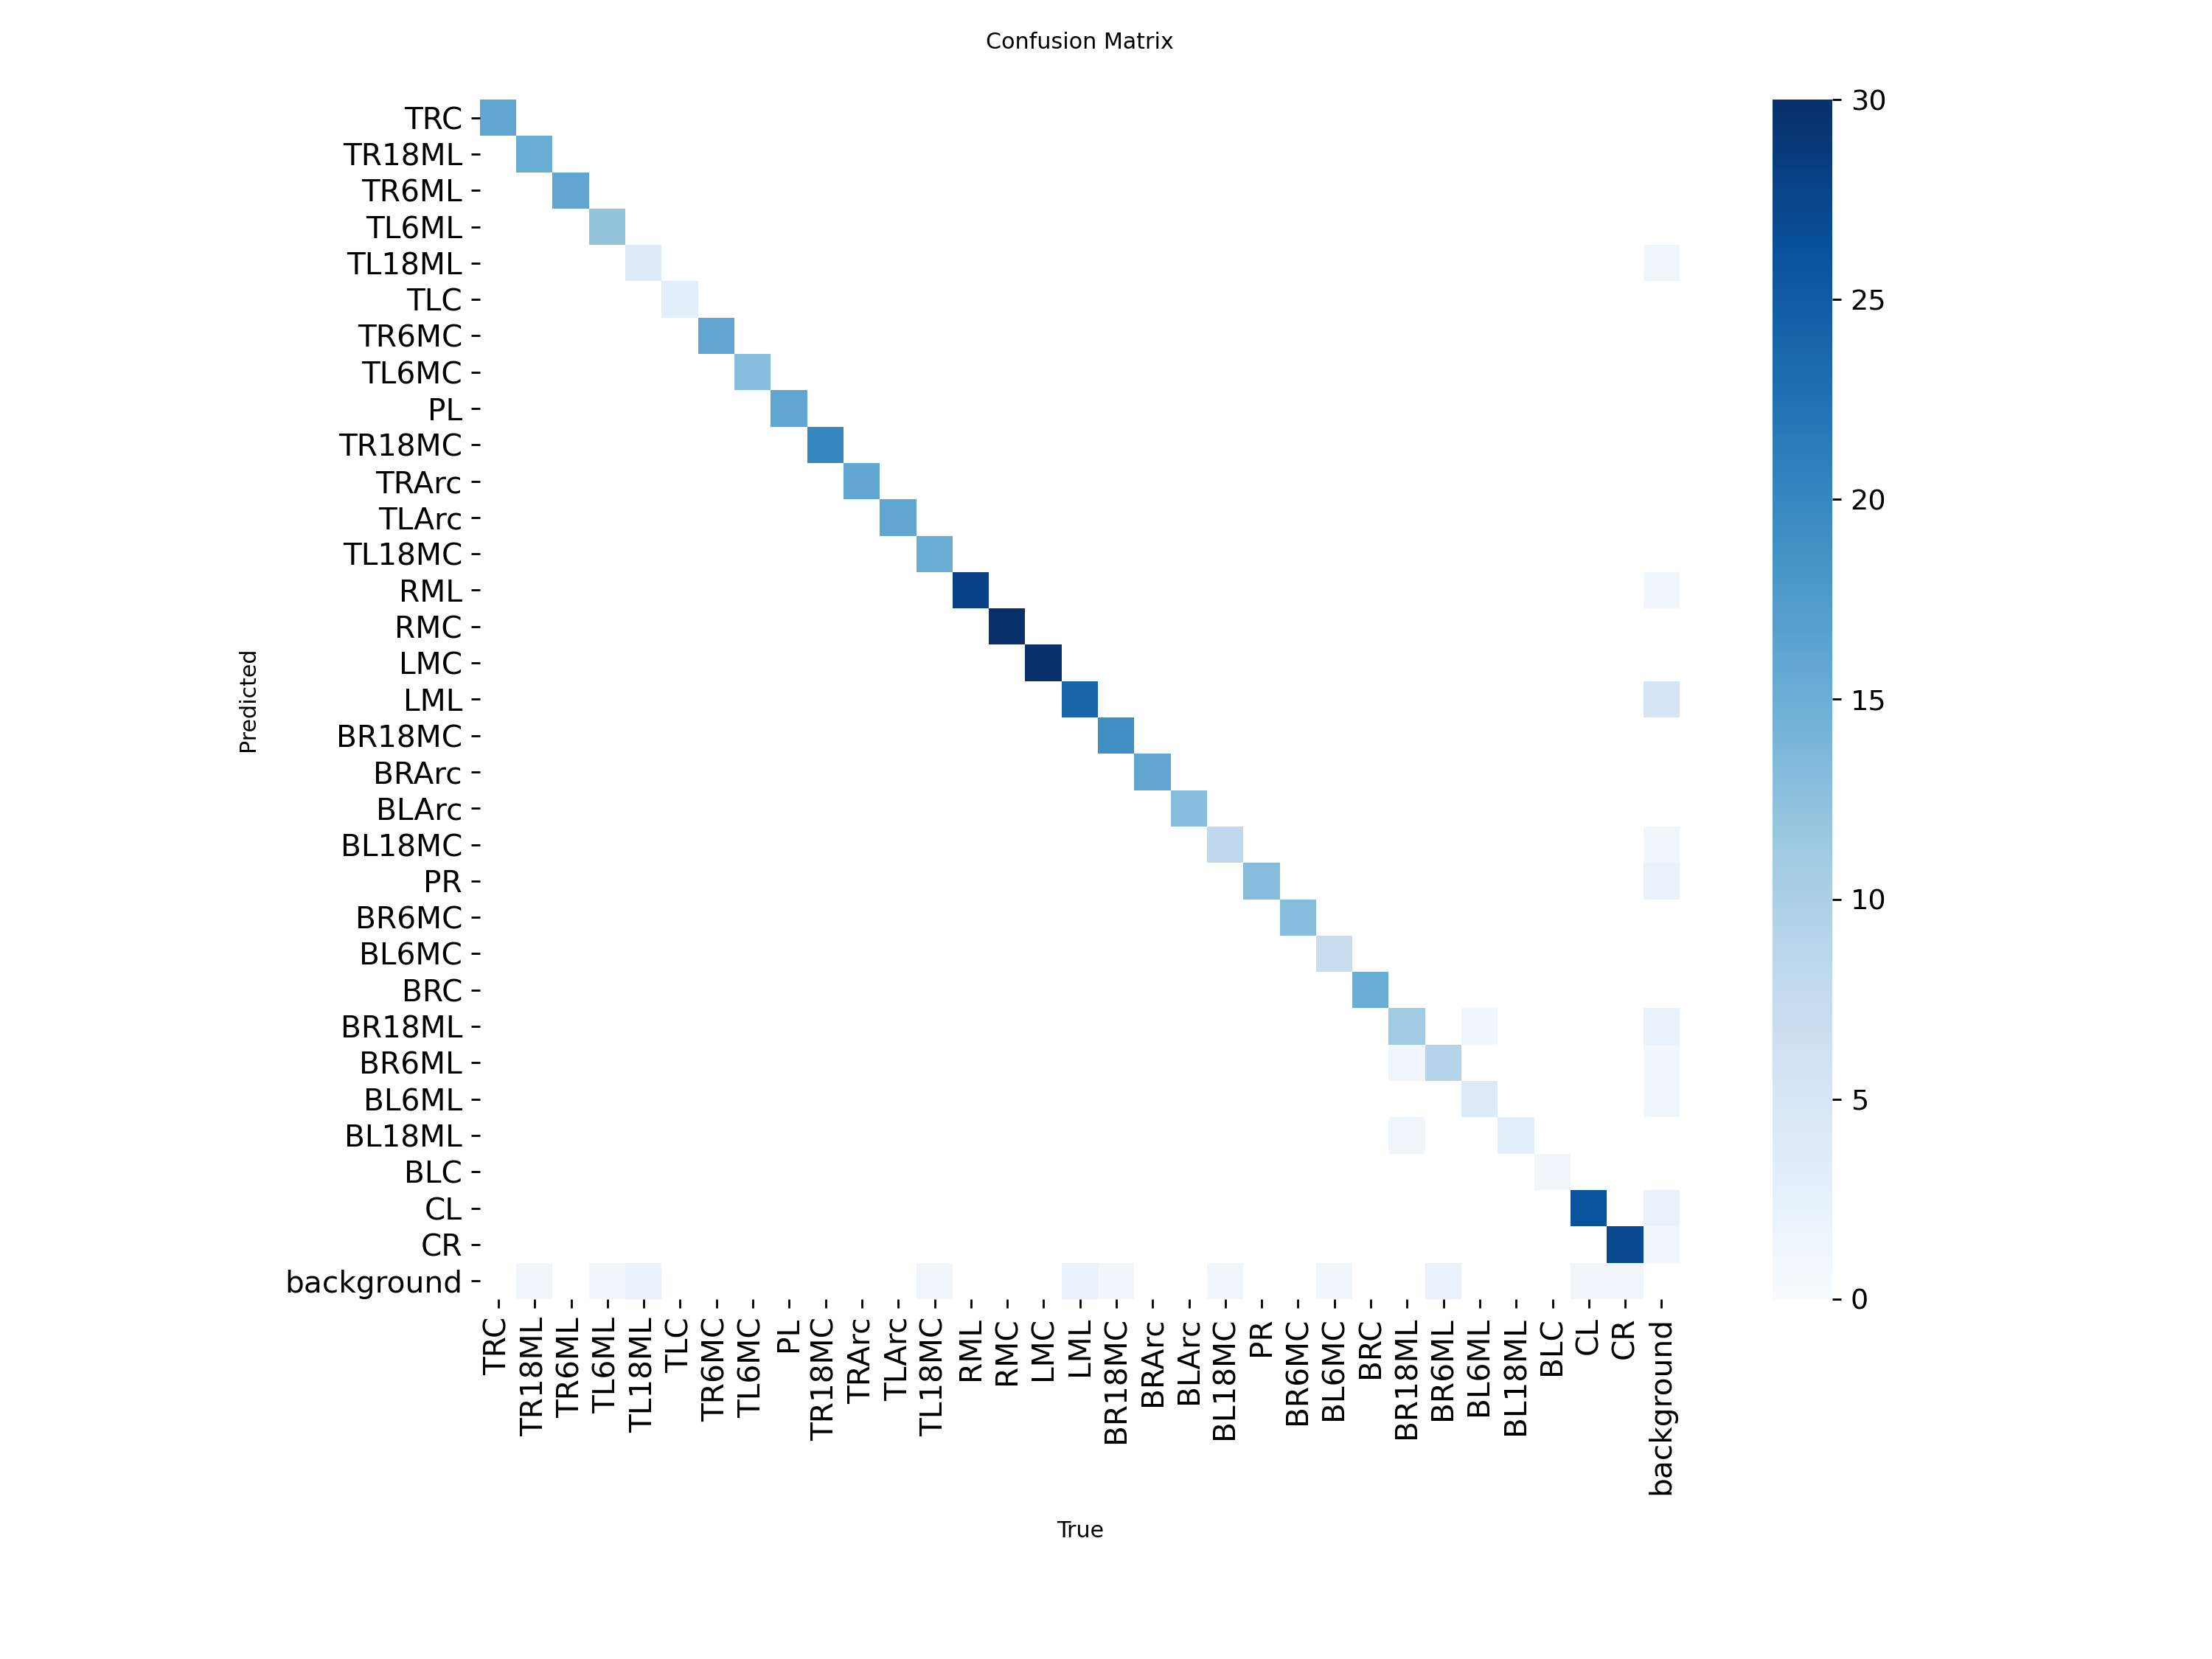

confusion_matrix_normalized.png


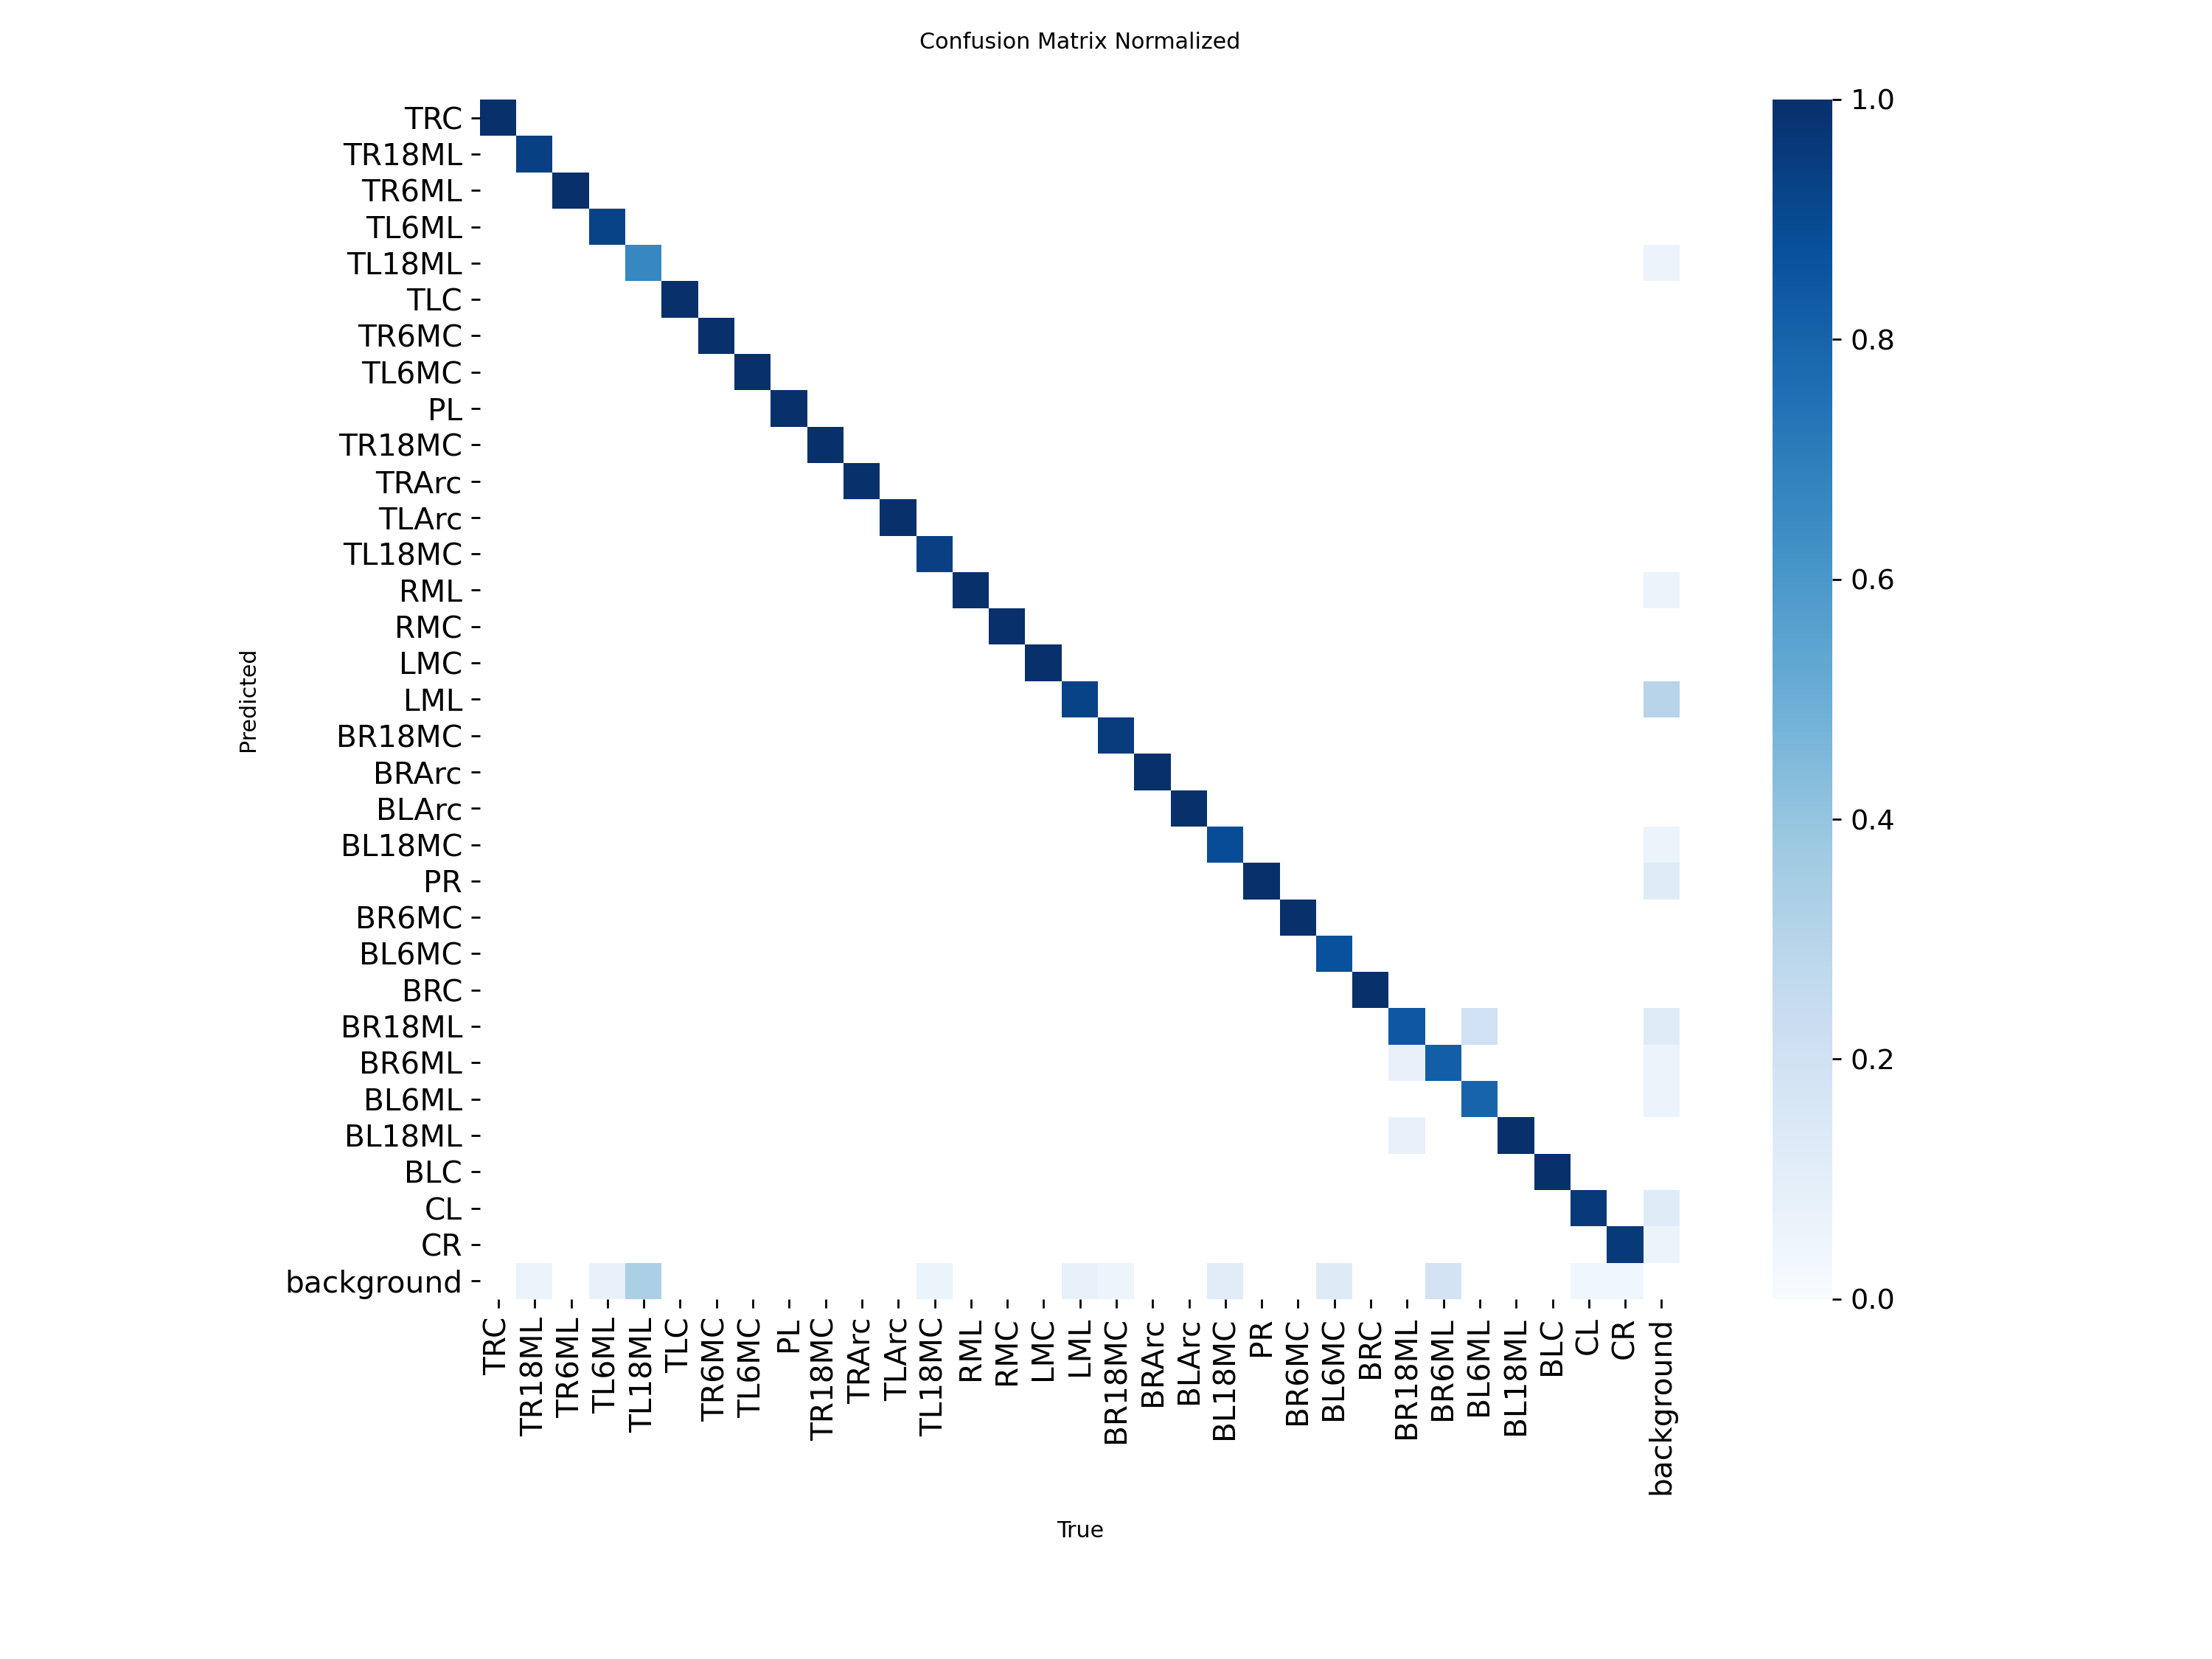

results.png


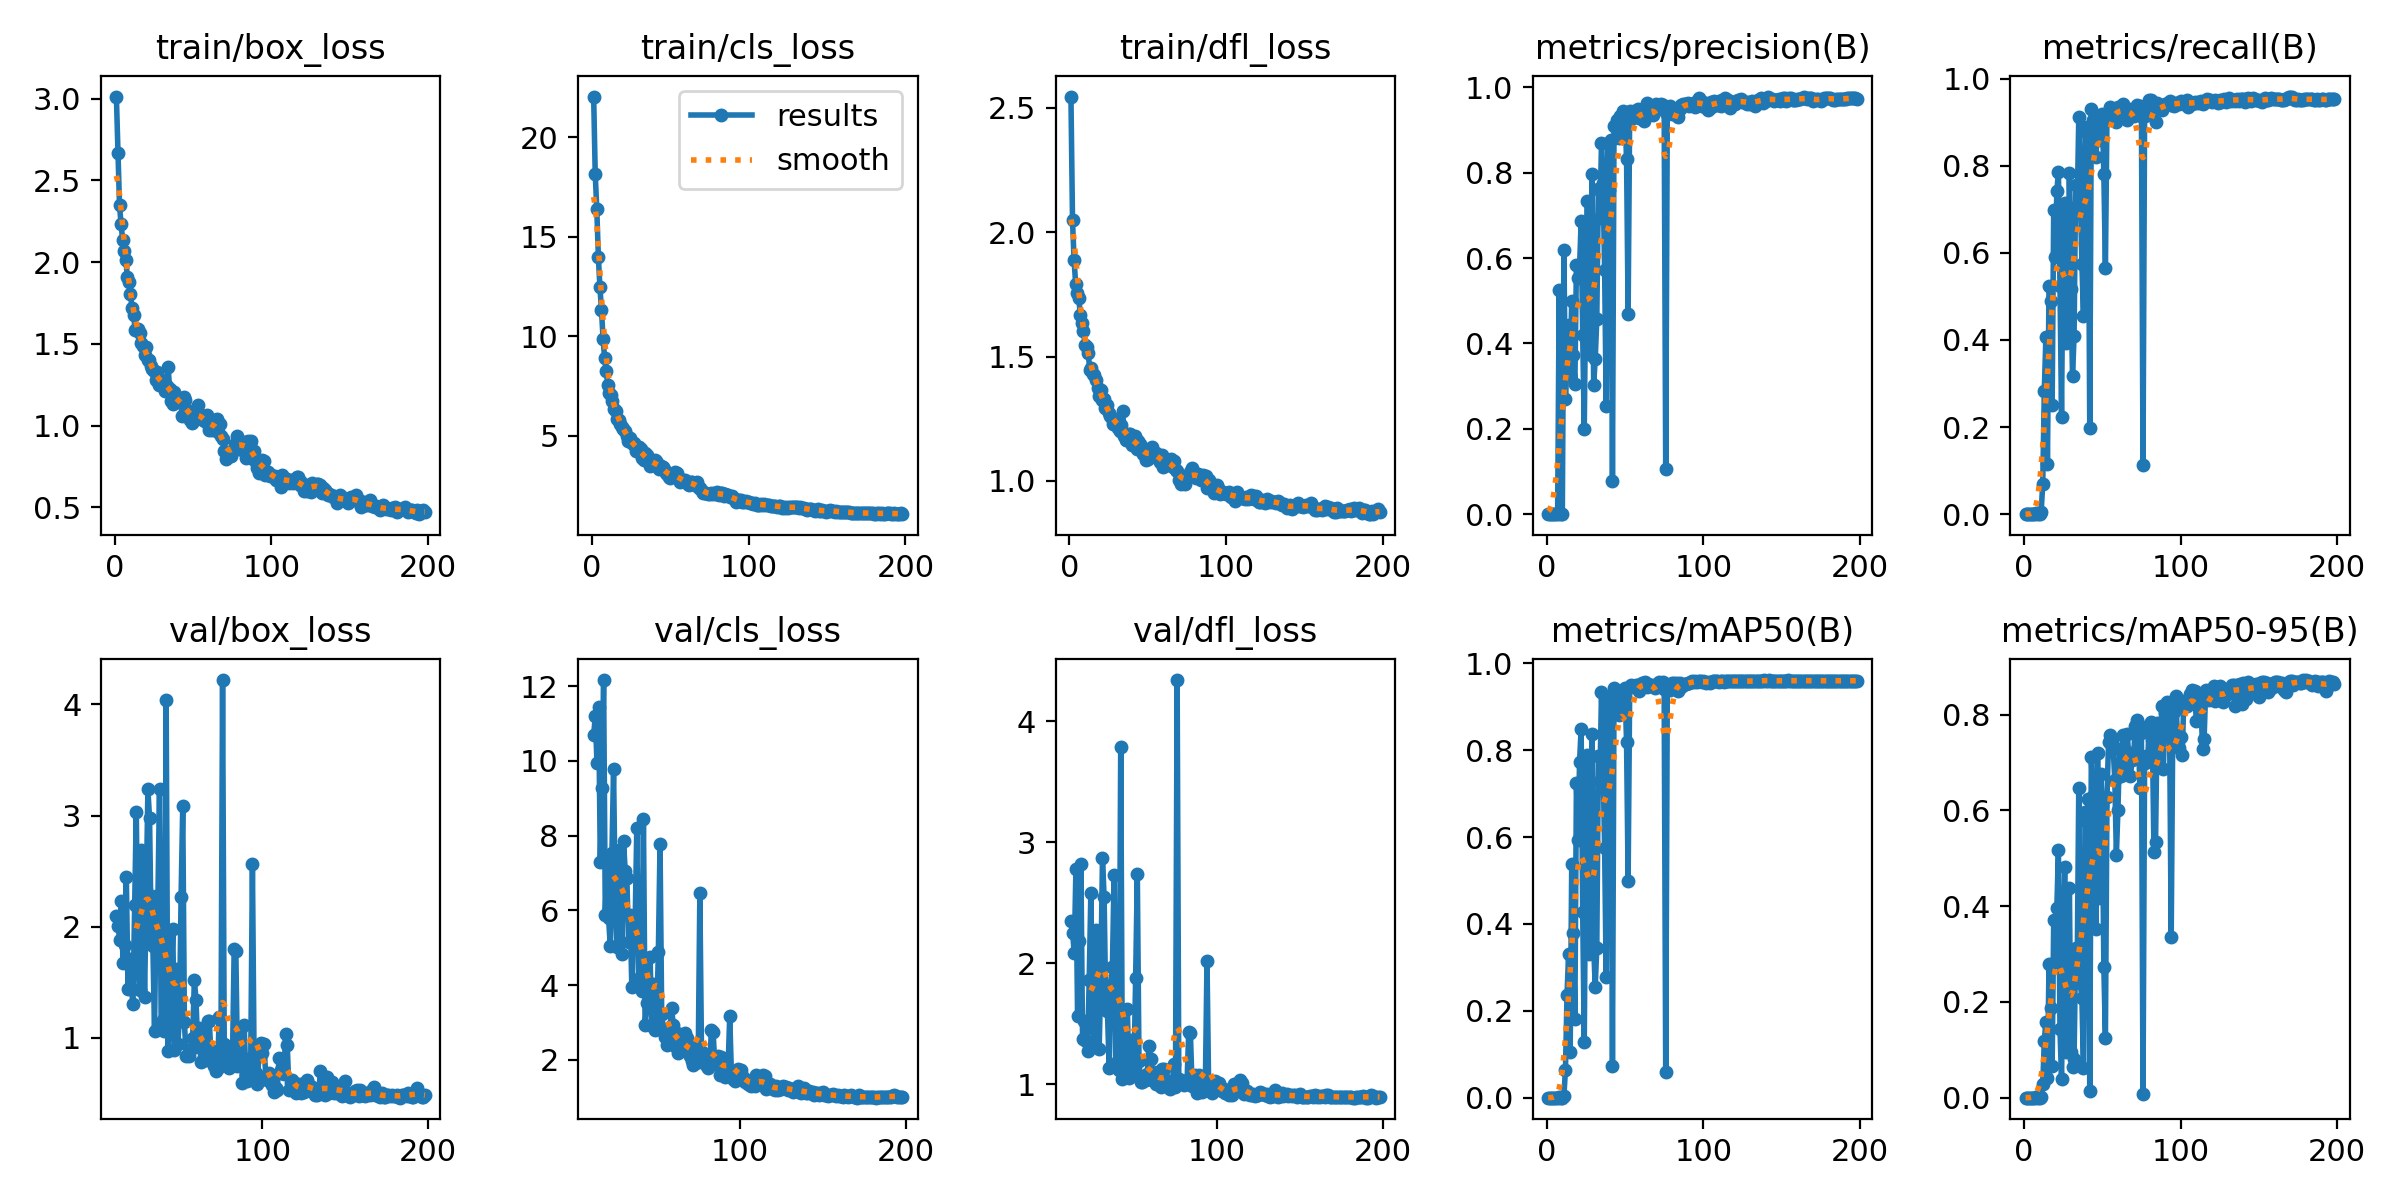

In [15]:
from IPython.display import Image as IPyImage, display

eval_plots = [
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
]

for plot_name in eval_plots:
    plot_path = os.path.join(EVAL_DIR, plot_name)
    if os.path.exists(plot_path):
        print(plot_name)
        display(IPyImage(filename=plot_path, width=800))

results_plot = os.path.join(RUN_DIR, "results.png")
if os.path.exists(results_plot):
    print("results.png")
    display(IPyImage(filename=results_plot, width=900))


## 7. Inference sanity check and extract landmark centers

At inference time, YOLO returns bounding boxes and class IDs. The **center of each
box** is the pitch landmark coordinate.

Because the model may occasionally return duplicate detections for the same landmark
class, the helper below keeps only the highest-confidence detection for each class.

Its output is exactly what the homography stage needs:

- `image_points`: detected `(x, y)` landmark centers in image pixels
- `landmark_indices`: their original landmark IDs `0..31`
- `confidences`: confidence for each accepted landmark



0: 960x960 1 TRC, 1 TR18ML, 1 TR6MC, 1 PL, 1 TR18MC, 1 TRArc, 1 TLArc, 1 RML, 1 RMC, 1 LMC, 1 LML, 1 BR18MC, 1 BRArc, 1 BLArc, 1 BRC, 1 BR18ML, 1 CL, 1 CR, 64.5ms
1: 960x960 1 RML, 1 RMC, 1 LMC, 1 LML, 1 BR18MC, 1 BRArc, 1 BLArc, 1 BL18MC, 1 PR, 1 BR6MC, 1 BL6MC, 1 BRC, 1 BR18ML, 1 BR6ML, 1 BL6ML, 1 CL, 1 CR, 64.5ms
2: 960x960 1 TRC, 1 TR18ML, 1 TR6ML, 1 TL6ML, 1 TL18ML, 1 TLC, 1 TR6MC, 1 TL6MC, 1 PL, 1 TR18MC, 1 TRArc, 1 TLArc, 1 TL18MC, 1 RML, 1 RMC, 1 LMC, 1 LML, 1 CL, 64.5ms
3: 960x960 1 TRC, 1 TR18ML, 1 TR6ML, 1 TL6ML, 1 TL18ML, 1 TLC, 1 TR6MC, 1 TL6MC, 1 PL, 1 TR18MC, 1 TRArc, 1 TLArc, 1 TL18MC, 1 RML, 1 RMC, 1 LMC, 1 LML, 1 CL, 64.5ms
4: 960x960 1 BR18MC, 1 BRArc, 1 BLArc, 1 BL18MC, 1 PR, 1 BR6MC, 1 BL6MC, 1 BRC, 1 BR18ML, 1 BR6ML, 1 BL6ML, 1 CR, 64.5ms
5: 960x960 1 TRC, 1 TR18ML, 1 PL, 1 TR18MC, 1 TRArc, 1 TLArc, 1 RML, 1 RMC, 1 LMC, 1 LML, 1 CL, 1 CR, 64.5ms
Speed: 2.7ms preprocess, 64.5ms inference, 1.3ms postprocess per image at shape (1, 3, 960, 960)
Results saved to /cont

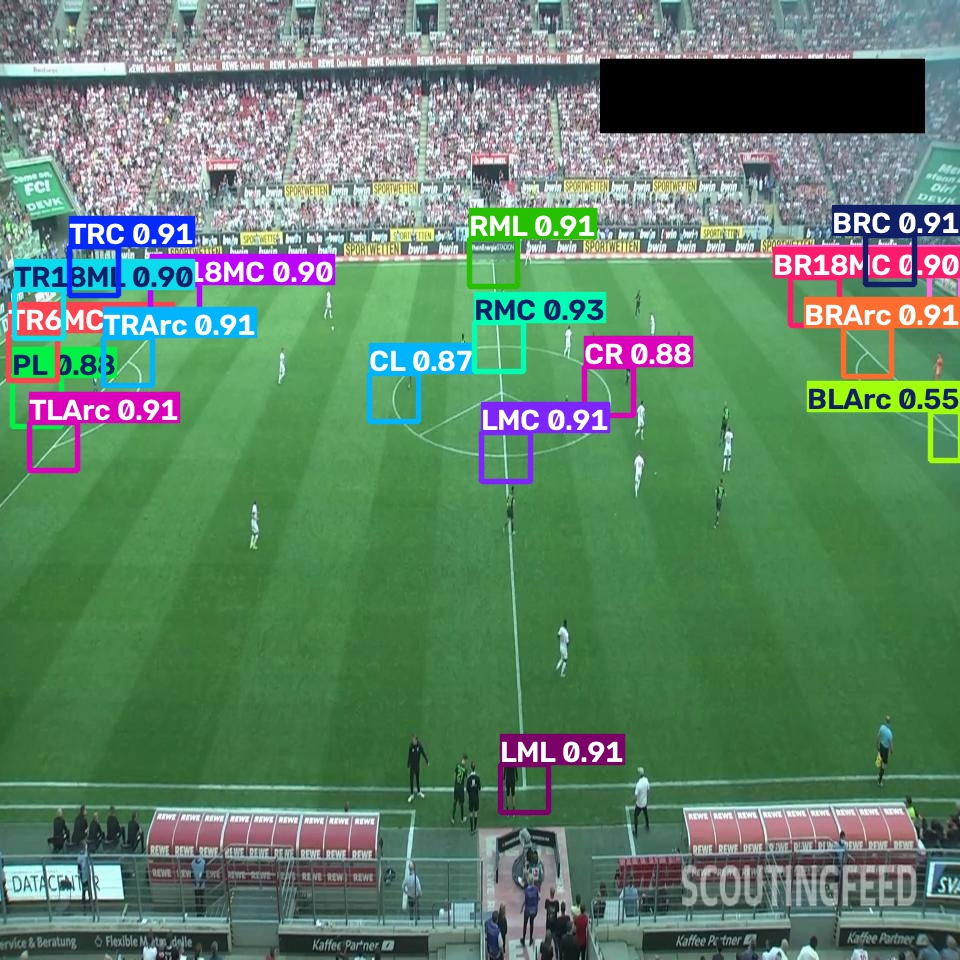

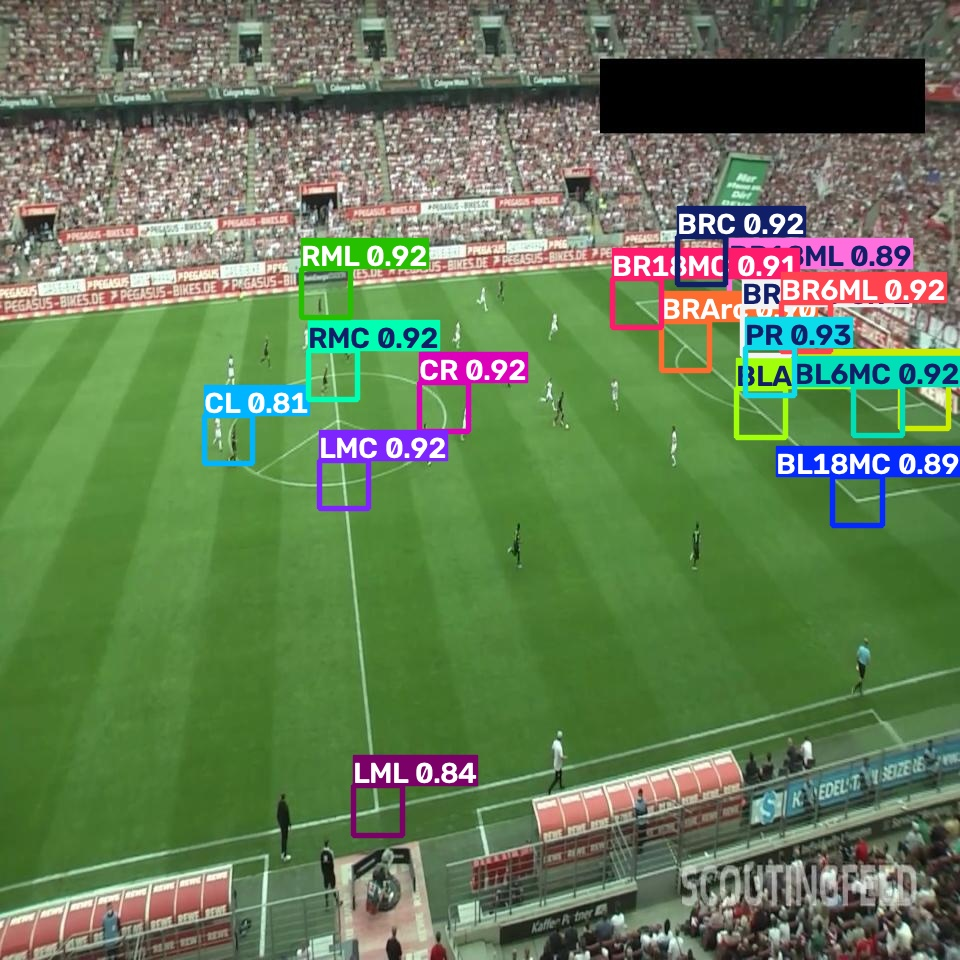

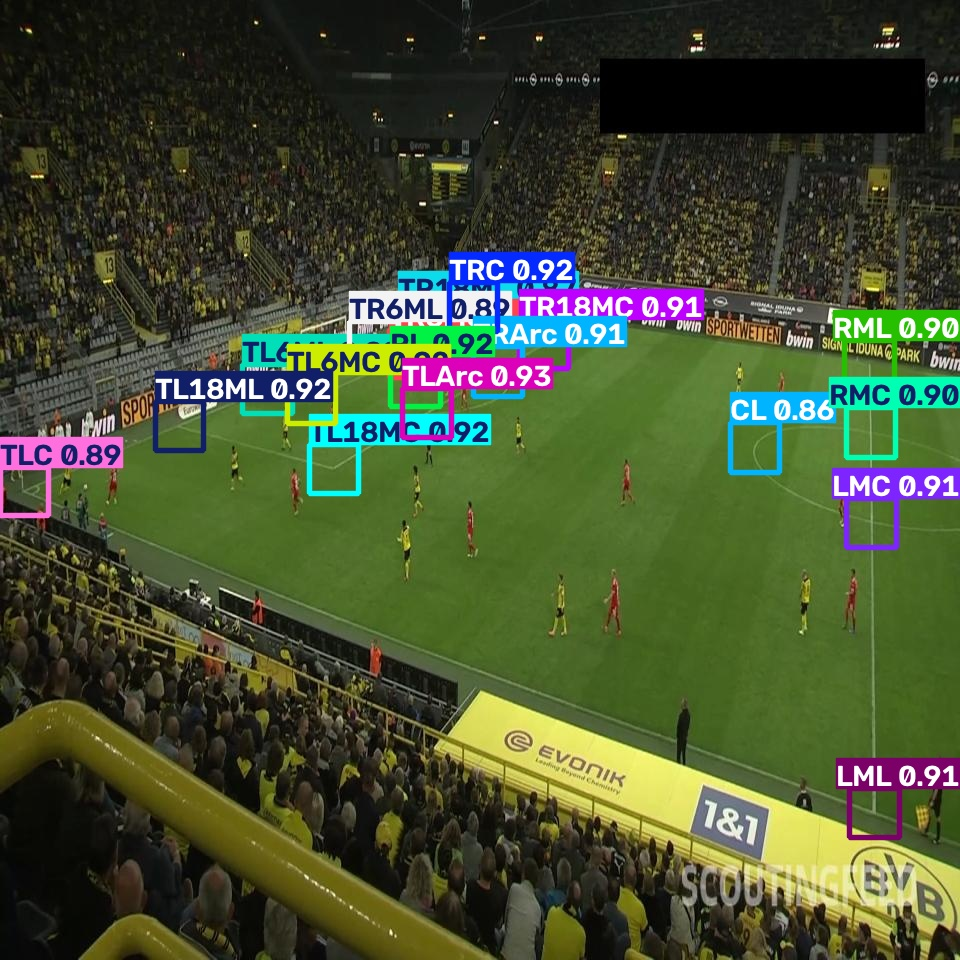

Annotated inference images saved to: /content/pitch_landmark_inference_samples


In [16]:
best_weights_path = os.path.join(RUN_DIR, "weights", "best.pt")
inference_model = YOLO(best_weights_path)

test_img_dir = (
    os.path.join(CONVERTED_DATASET_DIR, "test", "images")
    if os.path.isdir(os.path.join(CONVERTED_DATASET_DIR, "test", "images"))
    else os.path.join(CONVERTED_DATASET_DIR, "valid", "images")
)

test_imgs = []
for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"):
    test_imgs.extend(glob.glob(os.path.join(test_img_dir, ext)))

test_imgs = test_imgs[:6]

pred_results = inference_model.predict(
    source=test_imgs,
    imgsz=IMG_SIZE,
    conf=0.25,
    save=True,
    project=WORK_DIR,
    name="pitch_landmark_inference_samples",
    exist_ok=True,
)

for r in pred_results[:3]:
    saved_path = os.path.join(r.save_dir, os.path.basename(r.path))
    if os.path.exists(saved_path):
        display(IPyImage(filename=saved_path, width=800))

print(
    "Annotated inference images saved to:",
    os.path.join(WORK_DIR, "pitch_landmark_inference_samples")
)


Because the pitch landmarks are framed as object detection bounding boxes rather than explicit keypoints, YOLO may occasionally predict multiple overlapping bounding boxes for the same landmark class within a single frame.

The following utility function resolves this by:
1. **Filtering by Confidence:** Discarding any predictions below the specified confidence threshold (`min_conf`).
2. **Class Deduplication:** Retaining only the highest-confidence bounding box for each unique landmark class ID.
3. **Geometric Center Calculation:** Converting the bounding box coordinates $(x_1, y_1, x_2, y_2)$ into precise 2D pixel coordinates $(x, y)$ representing the center of the landmark.

This processed subset of **usable landmarks** serves as the clean input data required for downstream geometric estimation, such as computing homography matrices ($H$) and mapping image pixels to the 2D tactical field model.

In [17]:
def extract_landmark_centers(result, min_conf=0.5):
    """
    Keep the highest-confidence detection for each landmark class.

    Returns:
        image_points:      (N, 2) float32 pixel coordinates
        landmark_indices:  (N,) int class/keypoint indices
        confidences:       (N,) float32
    """
    if result.boxes is None or len(result.boxes) == 0:
        return (
            np.empty((0, 2), dtype=np.float32),
            np.empty((0,), dtype=int),
            np.empty((0,), dtype=np.float32),
        )

    xyxy = result.boxes.xyxy.cpu().numpy()
    class_ids = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    best_by_class = {}

    for box, class_id, conf in zip(xyxy, class_ids, confs):
        if conf < min_conf:
            continue

        previous = best_by_class.get(class_id)
        if previous is None or conf > previous[1]:
            best_by_class[class_id] = (box, conf)

    points = []
    indices = []
    confidences = []

    for class_id in sorted(best_by_class):
        box, conf = best_by_class[class_id]
        x1, y1, x2, y2 = box

        points.append([
            (x1 + x2) / 2.0,
            (y1 + y2) / 2.0,
        ])
        indices.append(class_id)
        confidences.append(conf)

    return (
        np.asarray(points, dtype=np.float32),
        np.asarray(indices, dtype=int),
        np.asarray(confidences, dtype=np.float32),
    )


sample_result = pred_results[0]

image_points, landmark_indices, confidences = extract_landmark_centers(
    sample_result,
    min_conf=0.5,
)

print(f"Usable landmarks: {len(image_points)}")
for idx, xy, conf in zip(landmark_indices, image_points, confidences):
    print(
        f"{idx:2d} {LANDMARK_NAMES[idx]:8s} "
        f"x={xy[0]:8.2f} y={xy[1]:8.2f} conf={conf:.3f}"
    )


Usable landmarks: 18
 0 TRC      x=   94.25 y=  271.31 conf=0.905
 1 TR18ML   x=   39.31 y=  313.73 conf=0.904
 6 TR6MC    x=   32.94 y=  356.38 conf=0.896
 8 PL       x=   36.68 y=  402.04 conf=0.877
 9 TR18MC   x=  175.39 y=  309.13 conf=0.901
10 TRArc    x=  127.96 y=  361.70 conf=0.911
11 TLArc    x=   53.42 y=  446.49 conf=0.913
13 RML      x=  493.34 y=  262.83 conf=0.911
14 RMC      x=  499.10 y=  346.84 conf=0.925
15 LMC      x=  505.81 y=  457.18 conf=0.913
16 LML      x=  524.34 y=  788.08 conf=0.911
17 BR18MC   x=  815.25 y=  301.42 conf=0.897
18 BRArc    x=  867.58 y=  352.08 conf=0.906
19 BLArc    x=  945.36 y=  436.39 conf=0.554
24 BRC      x=  889.95 y=  260.39 conf=0.906
25 BR18ML   x=  944.97 y=  300.50 conf=0.728
30 CL       x=  394.24 y=  397.33 conf=0.868
31 CR       x=  608.78 y=  390.97 conf=0.880


## 8. Save the model for the homography stage

The export contains the trained detector weights, evaluation artifacts, the converted
`data.yaml`, and the ordered 32-landmark class-name list.

For homography, class ID is the landmark identity. Real-world pitch coordinate
array must therefore use this exact same `0..31` ordering.


In [18]:
import json
import shutil

EXPORT_DIR = os.path.join(WORK_DIR, "pitch_landmarks_yolo11m_export")
os.makedirs(EXPORT_DIR, exist_ok=True)

shutil.copy(
    best_weights_path,
    os.path.join(EXPORT_DIR, "pitch_landmarks_yolo11m_best.pt")
)

last_weights_path = os.path.join(RUN_DIR, "weights", "last.pt")
if os.path.exists(last_weights_path):
    shutil.copy(
        last_weights_path,
        os.path.join(EXPORT_DIR, "pitch_landmarks_yolo11m_last.pt")
    )

shutil.copy(
    data_yaml_path,
    os.path.join(EXPORT_DIR, "data.yaml")
)

with open(os.path.join(EXPORT_DIR, "landmark_names.json"), "w") as f:
    json.dump(
        {i: name for i, name in enumerate(LANDMARK_NAMES)},
        f,
        indent=2,
    )

eval_export_dir = os.path.join(EXPORT_DIR, "evaluation")
os.makedirs(eval_export_dir, exist_ok=True)

for filename in [
    "landmark_detection_metrics_summary.csv",
    "per_landmark_map.csv",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
]:
    src = os.path.join(EVAL_DIR, filename)
    if os.path.exists(src):
        shutil.copy(src, eval_export_dir)

results_src = os.path.join(RUN_DIR, "results.png")
if os.path.exists(results_src):
    shutil.copy(results_src, eval_export_dir)

# Export validation ground-truth and prediction examples
for pattern in [
    "val_batch*_labels.jpg",
    "val_batch*_pred.jpg",
]:
    for src in glob.glob(os.path.join(RUN_DIR, pattern)):
        shutil.copy(src, eval_export_dir)

zip_path = shutil.make_archive(EXPORT_DIR, "zip", EXPORT_DIR)
print(f"Everything bundled at: {zip_path}")


Everything bundled at: /content/pitch_landmarks_yolo11m_export.zip


In [20]:
if PLATFORM == "colab":
    from google.colab import drive

    drive.mount("/content/drive")

    drive_target = "/content/drive/MyDrive/pitch_landmarks_yolo11_export.zip"
    shutil.copy(zip_path, drive_target)

    print(f"Copied to Google Drive: {drive_target}")

elif PLATFORM == "kaggle":
    print(
        "Running on Kaggle. Files under /kaggle/working are saved "
        "automatically as notebook Output."
    )
    print(f"Zip location: {zip_path}")

else:
    print(f"Zip location: {zip_path}")


Mounted at /content/drive
Copied to Google Drive: /content/drive/MyDrive/pitch_landmarks_yolo11_export.zip
